### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

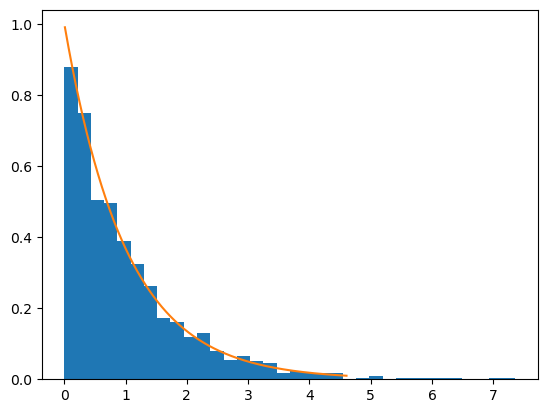

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

distGamma = sp.stats.gamma(a=1)
campione = distGamma.rvs(size=1000)
plt.hist(campione,density = True, bins='auto')
x = np.linspace(distGamma.ppf(0.01),
                distGamma.ppf(0.99),
                1000)
plt.plot(x, distGamma.pdf(x), label='PDF')



In [75]:
a,loc,scale = sp.stats.gamma.fit(campione)
print(f"a = {a},loc={loc},scale={scale}")

print(f"Il parametro di forma è {a}")

a = 0.9604367838146919,loc=0.001646702933398899,scale=1.055281425235818
Il parametro di forma è 0.9604367838146919


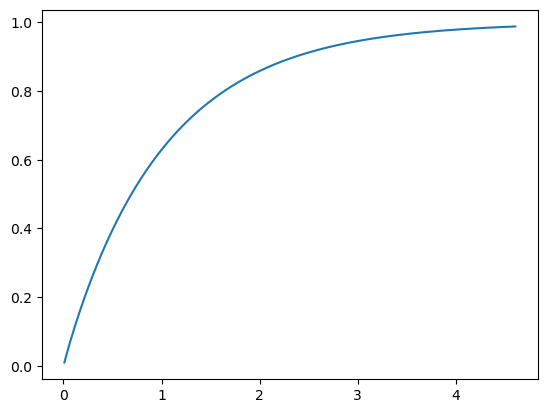

In [77]:
plt.plot(x,sp.stats.gamma.cdf(x,a,loc,scale))
plt.show()


In [78]:
print(f"La mediana è {sp.stats.gamma.median(a, loc=loc, scale=scale)}")

La mediana è 0.6927575929529975


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

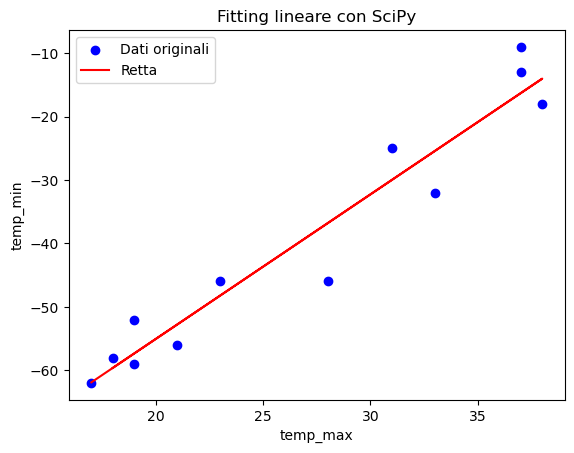

In [84]:
import numpy as np
import math
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt


slope, intercept, r_value, p_value, std_err = sp.stats.linregress(temp_max, temp_min)
slope, intercept, r_value, p_value, std_err

y_fit_sp = slope*temp_max + intercept


plt.scatter(temp_max, temp_min, label="Dati originali", color="blue")
plt.plot(temp_max, y_fit_sp, label="Retta", color="red")
plt.legend()
plt.xlabel("temp_max")
plt.ylabel("temp_min")
plt.title("Fitting lineare con SciPy")
plt.show()

In [87]:
def calculate_rmse(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range(len(y_real))) / len(y_real)
    return math.sqrt(mse)

def calculate_mae(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    errors = [abs(y_real[i] - y_pred[i]) for i in range(len(y_real))]
    return sum(errors) / len(errors)


mae_s = calculate_mae(temp_min, y_fit_sp)
rmse_s = calculate_rmse(temp_min, y_fit_sp)
print(f"MAE = {mae_s}, RMSE  = {rmse_s}")

MAE = 4.1224038134150485, RMSE  = 4.844160908155007


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [89]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


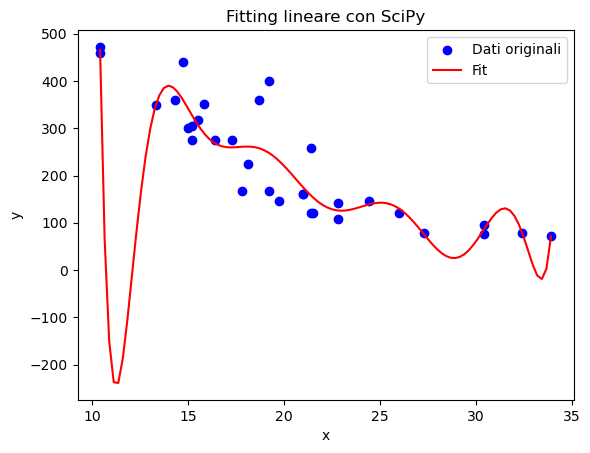

In [ ]:
x= df['mpg']
y= df['disp']

coeffs_deg = np.polyfit(x, y, deg=10)
poly_deg = np.poly1d(coeffs_deg)
x_fit = np.linspace(x.min(),x.max(),100)
y_fit_deg = poly_deg(x_fit)
y_pred_deg = poly_deg(x)
rmse_deg = np.sqrt(calculate_rmse(y, y_pred_deg))

plt.scatter(x, y, label="Dati originali", color="blue")
plt.plot(x_fit, y_fit_deg, label="Fit", color="red")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitting lineare con SciPy")
plt.show()